## Task 1 — Data Loading & Exploration


Load the CSV file using Pandas

In [3]:
import pandas as pd


In [4]:
df=pd.read_csv("Housing.csv")



 Display the first 10 rows


In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


 Check how many rows and columns are there


In [6]:
df.shape

(545, 13)

 Identify which column is the target (Price) and which are features


In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

 Check for missing values in each columns

In [8]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2 — Data Cleaning


Handle missing values (fill or drop, whichever fits the column)
 

In [9]:
#no missing values detected

Remove duplicate rows, if any


In [10]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding


In [11]:
df_encoded = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True
)

In [12]:
yes_no_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in yes_no_cols:
    df_encoded[col] = df_encoded[col].map({"yes":1,"no":0})

 Keep only the columns that are meaningful for predicting price

In [13]:
# All columns except price are meaningful predictors

## Task 3 — Model Building


Split the data into training and test sets (80/20)
 

In [14]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

Train a Linear Regression model to predict house price
 

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Evaluate it using MAE, RMSE, and R² Score


In [17]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R²: 0.6529242642153186


Train a second model — Random Forest Regressor

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest
MAE: 1014947.3230122325
RMSE: 1399769.443949671
R²: 0.6123598247296523


Comapring both the models


In [20]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr, mae_rf],
    "RMSE":[rmse_lr, rmse_rf],
    "R2 Score":[r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


## Task 4 — Visualizations

Chart 1: Histogram showing the distribution of house prices


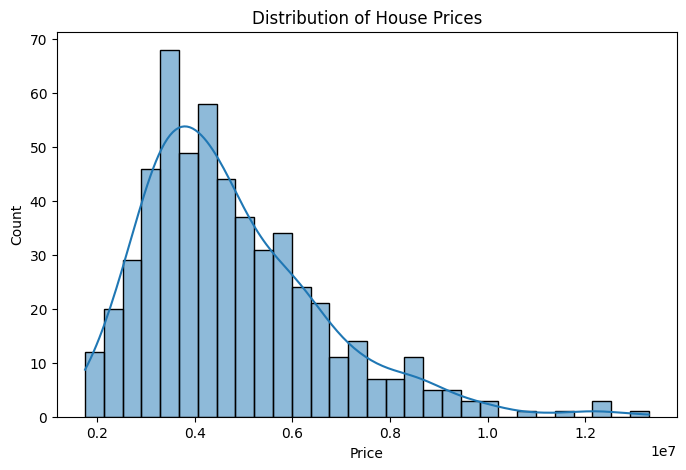

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("charts/price_distribution.png")
plt.show()

Chart 2: Correlation heatmap showing which features relate most strongly to price


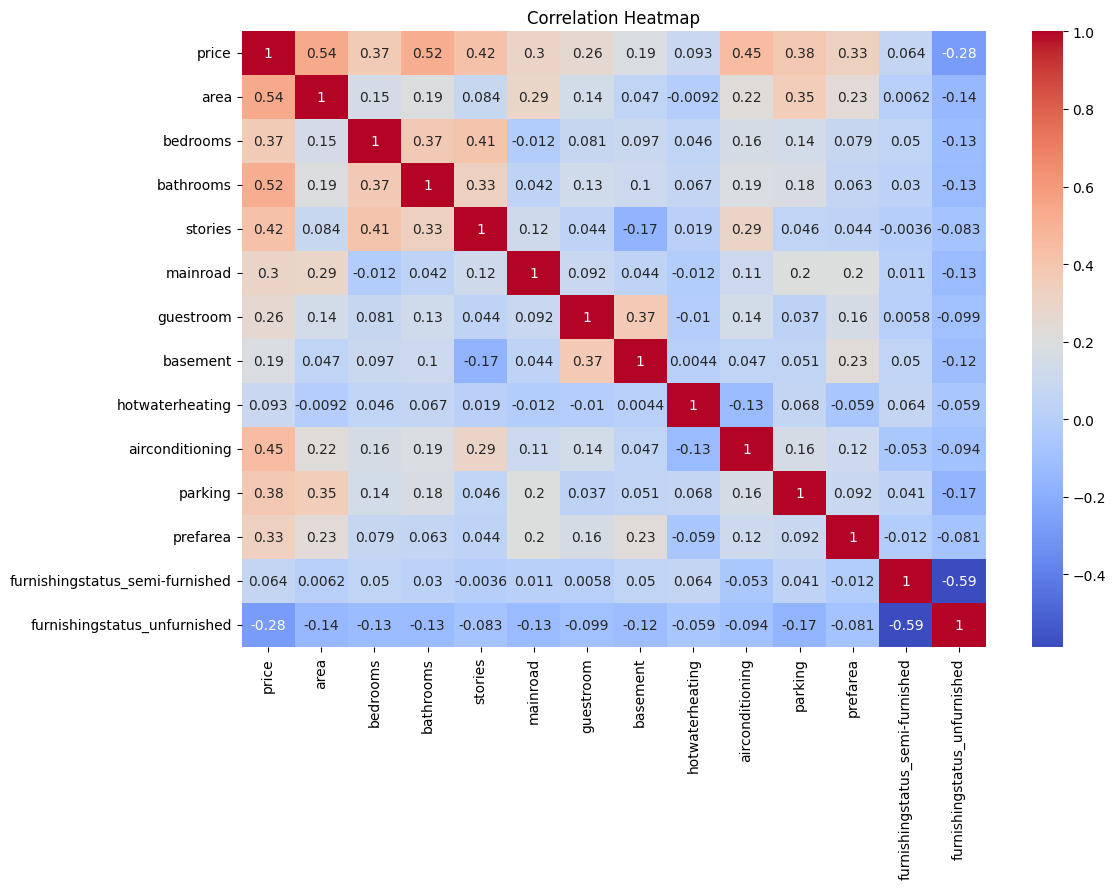

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")
plt.show()

actual vs. predicted price scatter plot

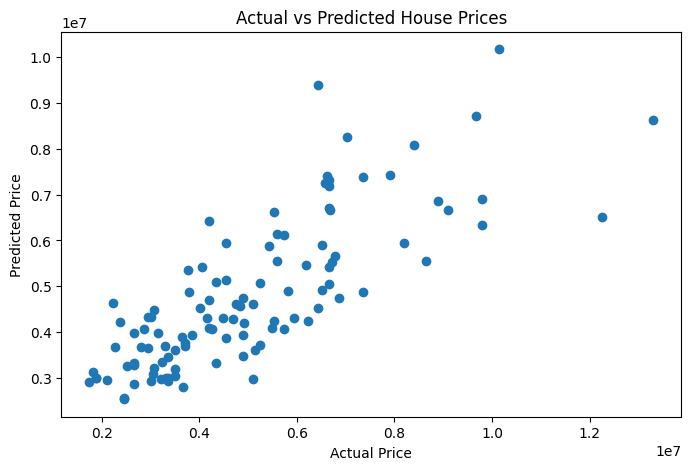

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")
plt.show()

Feature Importance

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,area,0.467809
2,bathrooms,0.152635
8,airconditioning,0.060260
9,parking,0.057557
3,stories,0.057045
1,bedrooms,0.047544
12,furnishingstatus_unfurnished,0.036974
6,basement,0.032418
10,prefarea,0.028316
7,hotwaterheating,0.018333


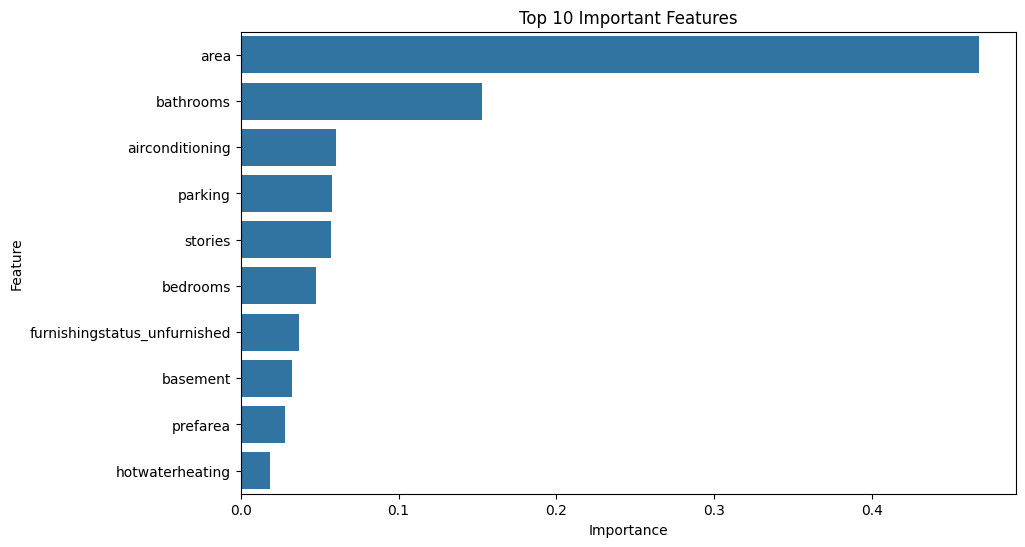

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig("charts/feature_importance.png")
plt.show()

## Task 5 — Insights & Summary


The objective of this project was to predict house prices using property-related features and identify the factors that most influence property value. After cleaning the dataset and training two regression models, Linear Regression achieved the best performance with an R² score of 0.653, outperforming the Random Forest Regressor. This indicates that the model was able to explain approximately 65% of the variation in house prices, making it reasonably effective for price estimation.

Feature importance analysis revealed that the area of a house is the most influential factor affecting price, followed by the number of bathrooms, air conditioning, parking availability, and the number of stories. These features contribute significantly more to price prediction than amenities such as hot water heating or basement availability.

One surprising observation was that the simpler Linear Regression model performed better than the more advanced Random Forest model. This suggests that the relationship between house features and price is largely linear within this dataset.

Based on these findings, real estate businesses should emphasize property size, modern amenities, and parking facilities in their marketing strategies, as these characteristics have the greatest impact on property valuation and buyer interest.
